# Computer Vision Project
### Parkinson Classification

This notebook contains the complete pipeline to load the PaHaW dataset, extract features from raw time-series data, train a classification model, and generate the final submission CSV.

### 1. Imports and Setup

In [5]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

# Set seaborn style for better plots
sns.set_theme(style="whitegrid")

### 2. Data Preparation and Feature Extraction
We extract statistical features for each variable (X, Y, Altitude, Azimuth, Pressure), calculate velocity, and count pen lifts. We also map the labels appropriately using the `Disease` column.

In [6]:
DATA_DIR = os.path.join('PaHaW', 'PaHaW_public')
LABELS_FILE = os.path.join('PaHaW', 'PaHaW_files', 'corpus_PaHaW.xlsx')
OUTPUT_FILE = 'dataset_features.csv'
EXCLUDE_SUBJECTS = ['00061', '00080', '00089']

def extract_features(file_path):
    # Columns: Y coordinate, X coordinate, time stamp, button state, azimuth, altitude, pressure
    try:
        df = pd.read_csv(file_path, sep=' ', header=None, skiprows=1, 
                         names=['Y', 'X', 'Time', 'Button', 'Azimuth', 'Altitude', 'Pressure'])
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

    if len(df) < 2:
        return None
        
    features = {}
    
    for col in ['X', 'Y', 'Pressure', 'Altitude', 'Azimuth']:
        features[f'{col}_mean'] = df[col].mean()
        features[f'{col}_std'] = df[col].std()
        features[f'{col}_min'] = df[col].min()
        features[f'{col}_max'] = df[col].max()
        features[f'{col}_median'] = df[col].median()
        
    features['Button_mean'] = df['Button'].mean()
    features['Pen_lifts'] = (df['Button'].diff() == -1).sum()
    features['Total_Duration'] = df['Time'].iloc[-1] - df['Time'].iloc[0]
    
    dx = df['X'].diff().fillna(0)
    dy = df['Y'].diff().fillna(0)
    dt = df['Time'].diff().fillna(0)
    dt_safe = dt.replace(0, 1e-6)
    v = np.sqrt(dx**2 + dy**2) / dt_safe
    v = v[1:]
    
    if len(v) > 0:
        features['Velocity_mean'] = v.mean()
        features['Velocity_std'] = v.std()
        features['Velocity_max'] = v.max()
    else:
        features['Velocity_mean'] = 0
        features['Velocity_std'] = 0
        features['Velocity_max'] = 0
        
    return features

def prepare_dataset():
    print("Loading labels...")
    df_labels = pd.read_excel(LABELS_FILE)
    df_labels['ID'] = df_labels['ID'].astype(str).str.zfill(5)
    # Target mapping: PD -> 1, Healthy -> 0
    labels_dict = dict(zip(df_labels['ID'], (df_labels['Disease'] == 'PD').astype(int)))
    
    dataset = []
    subject_dirs = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    print(f"Found {len(subject_dirs)} subject directories.")
    
    for subject_id in subject_dirs:
        if subject_id in EXCLUDE_SUBJECTS:
            continue
        if subject_id not in labels_dict:
            continue
            
        subject_path = os.path.join(DATA_DIR, subject_id)
        svc_files = glob.glob(os.path.join(subject_path, "*.svc"))
        
        subject_features_list = []
        for svc_file in svc_files:
            feats = extract_features(svc_file)
            if feats is not None:
                subject_features_list.append(feats)
                
        if subject_features_list:
            df_subj = pd.DataFrame(subject_features_list)
            subj_avg_features = df_subj.mean().to_dict()
            subj_avg_features['Subject_ID'] = subject_id
            subj_avg_features['Label'] = labels_dict[subject_id]
            dataset.append(subj_avg_features)
            
    print(f"Extracted features for {len(dataset)} subjects.")
    final_df = pd.DataFrame(dataset)
    cols = ['Subject_ID', 'Label'] + [c for c in final_df.columns if c not in ['Subject_ID', 'Label']]
    final_df = final_df[cols]
    final_df.to_csv(OUTPUT_FILE, index=False)
    print(f"Dataset saved to {OUTPUT_FILE}")
    return final_df

df = prepare_dataset()
df.head()

Loading labels...
Found 75 subject directories.
Extracted features for 72 subjects.
Dataset saved to dataset_features.csv


,Subject_ID,Label,X_mean,X_std,X_min,X_max,X_median,Y_mean,Y_std,Y_min,...,Azimuth_std,Azimuth_min,Azimuth_max,Azimuth_median,Button_mean,Pen_lifts,Total_Duration,Velocity_mean,Velocity_std,Velocity_max
0,00001,1,5732.951090,783.649038,4382.500,7122.250,5773.8750,3735.355171,161.139365,3359.500,...,239.306544,2674.125,3394.625,2826.125,0.851733,5.625,11841.250,0.996102,0.658571,4.069908
1,00002,1,5683.799917,698.694539,4474.125,6889.875,5655.5000,3707.495186,131.557586,3444.375,...,47.756432,2946.750,3222.625,3098.875,0.858910,4.125,20458.625,0.693606,0.526317,4.328476
2,00003,1,5821.983805,764.986517,4452.000,7135.125,5845.7500,3750.788889,144.025944,3435.125,...,64.839056,2961.750,3301.000,3118.750,0.851108,4.250,20394.000,0.642324,0.479275,3.845457
3,00004,1,5876.796813,762.694510,4432.500,7328.875,5874.0000,3747.437887,148.195066,3390.250,...,46.831733,3068.500,3399.375,3220.625,0.722784,8.500,21218.500,1.044882,1.188182,11.528902
4,00005,1,5358.695924,491.340899,4504.375,6186.750,5374.8125,3647.055423,93.976834,3454.375,...,42.071587,2992.625,3178.750,3079.750,0.782451,6.875,26519.625,0.372317,0.348071,2.573244


### 3. Baseline Model Training and Evaluation
We use a Random Forest model, evaluate it with 5-Fold Stratified Cross Validation, and generate predictions on a 20% hold-out test split.

In [7]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# Separate features and labels
X = df.drop(columns=['Subject_ID', 'Label'])
y = df['Label']
subject_ids = df['Subject_ID']

print(f"Dataset shape: {X.shape}")

# 80-20 train-test split
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, subject_ids, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=7, 
    min_samples_split=5, 
    min_samples_leaf=2, 
    max_features='sqrt',
    random_state=42, 
    class_weight='balanced'
)


# Evaluate using Stratified 5-Fold Cross Validation
print("\n--- 5-Fold Cross Validation on Training Set ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    model, X_train_scaled, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print(f"CV Accuracy:  {np.mean(cv_results['test_accuracy']):.4f} ± {np.std(cv_results['test_accuracy']):.4f}")
print(f"CV Precision: {np.mean(cv_results['test_precision']):.4f} ± {np.std(cv_results['test_precision']):.4f}")
print(f"CV Recall:    {np.mean(cv_results['test_recall']):.4f} ± {np.std(cv_results['test_recall']):.4f}")
print(f"CV F1-Score:  {np.mean(cv_results['test_f1']):.4f} ± {np.std(cv_results['test_f1']):.4f}")
print(f"CV AUC:       {np.mean(cv_results['test_roc_auc']):.4f} ± {np.std(cv_results['test_roc_auc']):.4f}")

# Train on the full training set and evaluate on test set
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Hold-Out Test Set Evaluation ---")
print(f"Accuracy:    {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred):.4f}")
print(f"Specificity: {specificity_score(y_test, y_pred):.4f}")
print(f"F1-Score:    {f1_score(y_test, y_pred):.4f}")
print(f"AUC:         {roc_auc_score(y_test, y_prob):.4f}")

Dataset shape: (72, 31)
Training set: 57 samples
Test set: 15 samples

--- 5-Fold Cross Validation on Training Set ---
CV Accuracy:  0.6636 ± 0.1593
CV Precision: 0.6683 ± 0.1818
CV Recall:    0.6200 ± 0.2446
CV F1-Score:  0.6328 ± 0.2124
CV AUC:       0.6689 ± 0.1399

--- Hold-Out Test Set Evaluation ---
Accuracy:    0.6667
Precision:   0.6250
Recall:      0.7143
Specificity: 0.6250
F1-Score:    0.6667
AUC:         0.7143


### 4. Visualizations
Here we visualize the Feature Importances, the Confusion Matrix, and the ROC Curve.

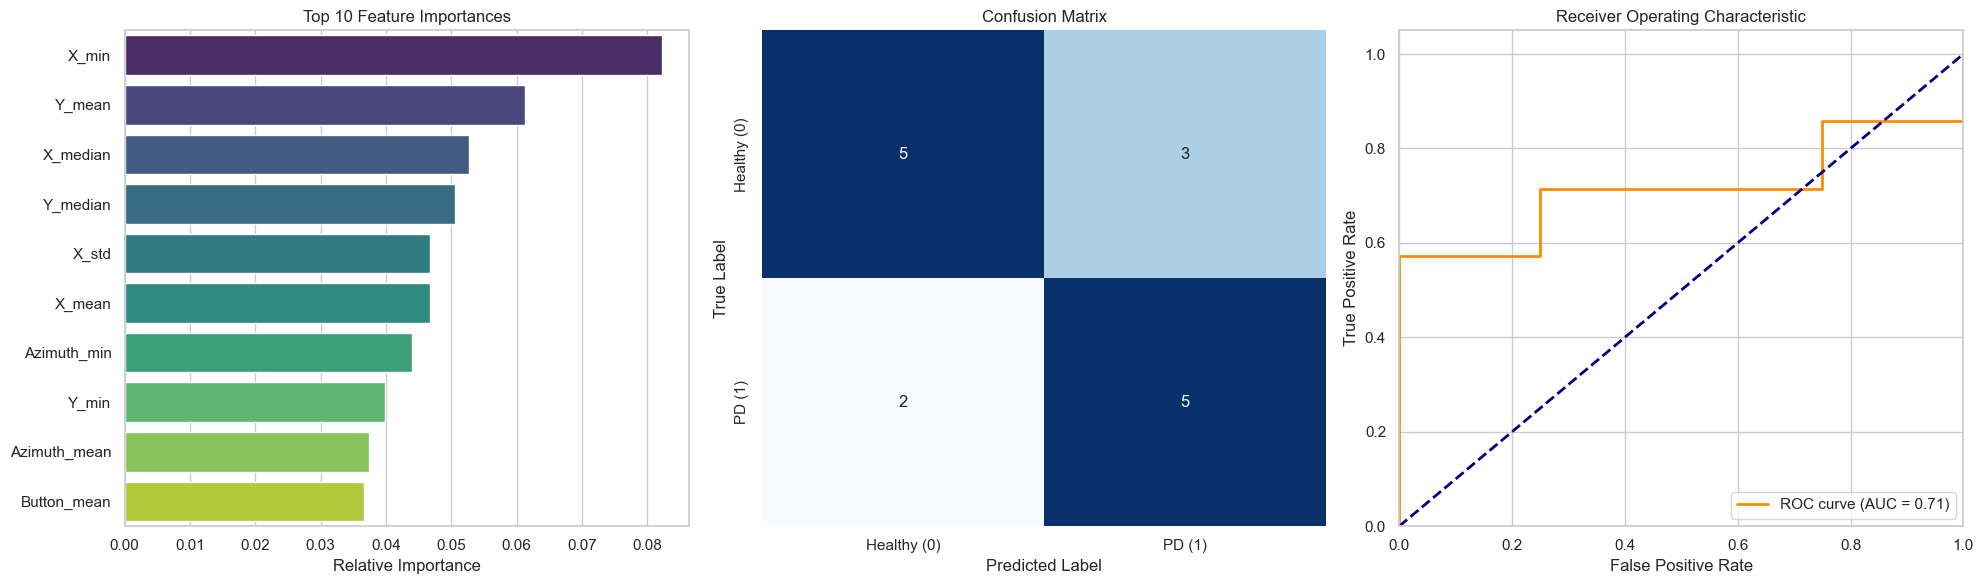

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Feature Importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10
top_indices = indices[:top_n]
top_features = X.columns[top_indices]
top_importances = importances[top_indices]

sns.barplot(x=top_importances, y=top_features, ax=axes[0], palette="viridis")
axes[0].set_title(f"Top {top_n} Feature Importances")
axes[0].set_xlabel("Relative Importance")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar=False, 
            xticklabels=['Healthy (0)', 'PD (1)'], yticklabels=['Healthy (0)', 'PD (1)'])
axes[1].set_title("Confusion Matrix")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Receiver Operating Characteristic')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

### 5. Create Submission CSV

In [9]:
SUBMISSION_FILE = 'submission.csv'

submission_df = pd.DataFrame({
    'ID': ids_test.astype(str).str.zfill(5),
    'PD status': y_pred.astype(int)
})
submission_df.to_csv(SUBMISSION_FILE, index=False)
print(f"Submission file saved to '{SUBMISSION_FILE}'.")
submission_df.head()

Submission file saved to 'submission.csv'.


,ID,PD status
63,00087,0
28,00032,1
3,00004,1
17,00020,1
58,00078,0


### 6. Interactive Dashboard
Run the cell below to launch the Streamlit dashboard.

In [10]:
import sys
import subprocess

print("[*] Starting Streamlit server in the background...")

# Use Popen instead of run. This spawns the process and immediately moves on.
streamlit_process = subprocess.Popen([sys.executable, "-m", "streamlit", "run", "scripts/app.py"])

print(f"[✔] Streamlit is running in the background (PID: {streamlit_process.pid}).")
print("[*] You can now continue using the notebook!")

[*] Starting Streamlit server in the background...
[✔] Streamlit is running in the background (PID: 5392).
[*] You can now continue using the notebook!


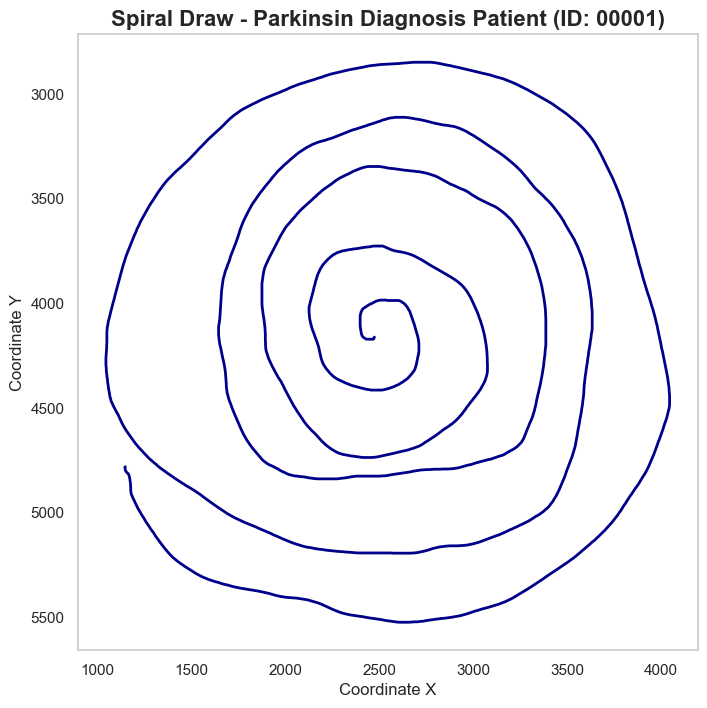

In [11]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Definiamo le directory (usando quelle già presenti nel tuo notebook)
DATA_DIR = os.path.join('PaHaW', 'PaHaW_public')
LABELS_FILE = os.path.join('PaHaW', 'PaHaW_files', 'corpus_PaHaW.xlsx')
EXCLUDE_SUBJECTS = ['00061', '00080', '00089']

# 1. Leggiamo le etichette per trovare un paziente malato (PD)
df_labels = pd.read_excel(LABELS_FILE)
df_labels['ID'] = df_labels['ID'].astype(str).str.zfill(5)
parkinson_patients = df_labels[df_labels['Disease'] == 'PD']['ID'].tolist()

# 2. Prendiamo il primo paziente malato valido
valid_pd_patients = [p for p in parkinson_patients if p not in EXCLUDE_SUBJECTS]
selected_patient = valid_pd_patients[0]

# 3. Troviamo i file .svc (le prove) per questo paziente
subject_path = os.path.join(DATA_DIR, selected_patient)
svc_files = glob.glob(os.path.join(subject_path, "*.svc"))

if svc_files:
    # Prendiamo la prima prova del paziente (il primo file .svc)
    file_path = svc_files[0]
    
    # 4. Leggiamo i dati grezzi della time-series
    df_spiral = pd.read_csv(file_path, sep=' ', header=None, skiprows=1, 
                            names=['Y', 'X', 'Time', 'Button', 'Azimuth', 'Altitude', 'Pressure'])
    
    # 5. Creiamo il plot dell'immagine
    plt.figure(figsize=(8, 8))
    
    # Filtriamo solo i punti in cui la penna tocca effettivamente il tablet (Button == 1)
    pen_down = df_spiral[df_spiral['Button'] == 1]
    
    plt.plot(pen_down['X'], pen_down['Y'], color='darkblue', linewidth=2)
    
    plt.title(f'Spiral Draw - Parkinsin Diagnosis Patient (ID: {selected_patient})', fontsize=16, fontweight='bold')
    plt.xlabel('Coordinate X', fontsize=12)
    plt.ylabel('Coordinate Y', fontsize=12)
    
    # Invertire l'asse Y rende il disegno visivamente corretto.
    plt.gca().invert_yaxis()
    
    # Rimuoviamo la griglia per far sembrare il plot più "un'immagine" pulita
    plt.grid(False) 
    
    plt.show()
else:
    print(f"Nessun file trovato per il paziente {selected_patient}.")

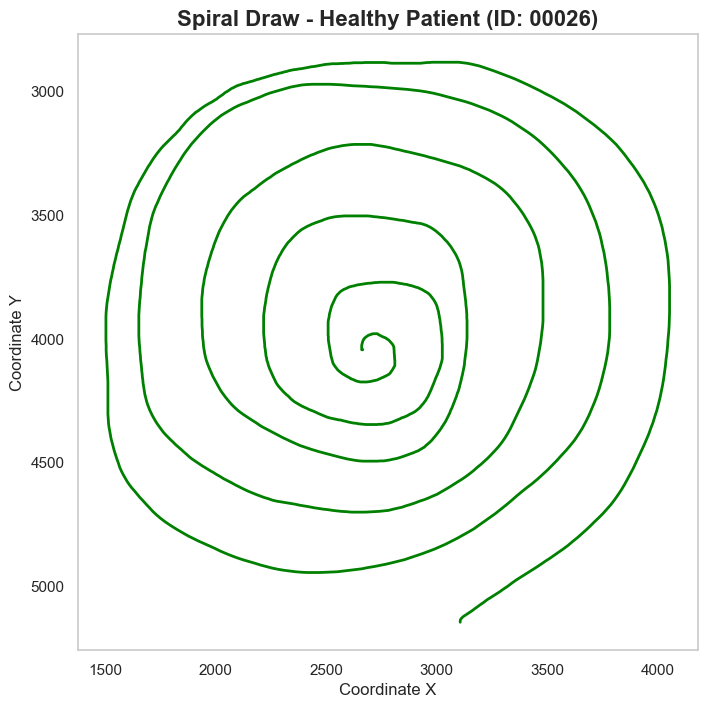

In [12]:
# Paziente Sano (Senza Parkinson)

# 1. Leggiamo le etichette per trovare un paziente sano (diverso da PD)
healthy_patients = df_labels[df_labels['Disease'] != 'PD']['ID'].tolist()

# 2. Prendiamo il primo paziente sano valido
valid_hc_patients = [p for p in healthy_patients if p not in EXCLUDE_SUBJECTS]
selected_patient_hc = valid_hc_patients[0]

# 3. Troviamo i file .svc (le prove) per questo paziente
subject_path_hc = os.path.join(DATA_DIR, selected_patient_hc)
svc_files_hc = glob.glob(os.path.join(subject_path_hc, "*.svc"))

if svc_files_hc:
    # Prendiamo la prima prova del paziente (il primo file .svc)
    file_path_hc = svc_files_hc[0]
    
    # 4. Leggiamo i dati grezzi della time-series
    df_spiral_hc = pd.read_csv(file_path_hc, sep=' ', header=None, skiprows=1, 
                            names=['Y', 'X', 'Time', 'Button', 'Azimuth', 'Altitude', 'Pressure'])
    
    # 5. Creiamo il plot dell'immagine
    plt.figure(figsize=(8, 8))
    
    # Filtriamo solo i punti in cui la penna tocca effettivamente il tablet (Button == 1)
    pen_down_hc = df_spiral_hc[df_spiral_hc['Button'] == 1]
    
    plt.plot(pen_down_hc['X'], pen_down_hc['Y'], color='green', linewidth=2)
    
    plt.title(f'Spiral Draw - Healthy Patient (ID: {selected_patient_hc})', fontsize=16, fontweight='bold')
    plt.xlabel('Coordinate X', fontsize=12)
    plt.ylabel('Coordinate Y', fontsize=12)
    
    # Invertire l'asse Y rende il disegno visivamente corretto.
    plt.gca().invert_yaxis()
    
    # Rimuoviamo la griglia per far sembrare il plot più "un'immagine" pulita
    plt.grid(False) 
    
    plt.show()
else:
    print(f"No file found for the patient {selected_patient_hc}.")

--- Model Comparison (5-Fold Cross Validation Accuracy) ---
Logistic Regression : 0.6303 ± 0.1066
KNN                 : 0.6803 ± 0.1631
SVM                 : 0.7182 ± 0.2103
Gradient Boosting   : 0.5576 ± 0.1357
Random Forest       : 0.6636 ± 0.1593


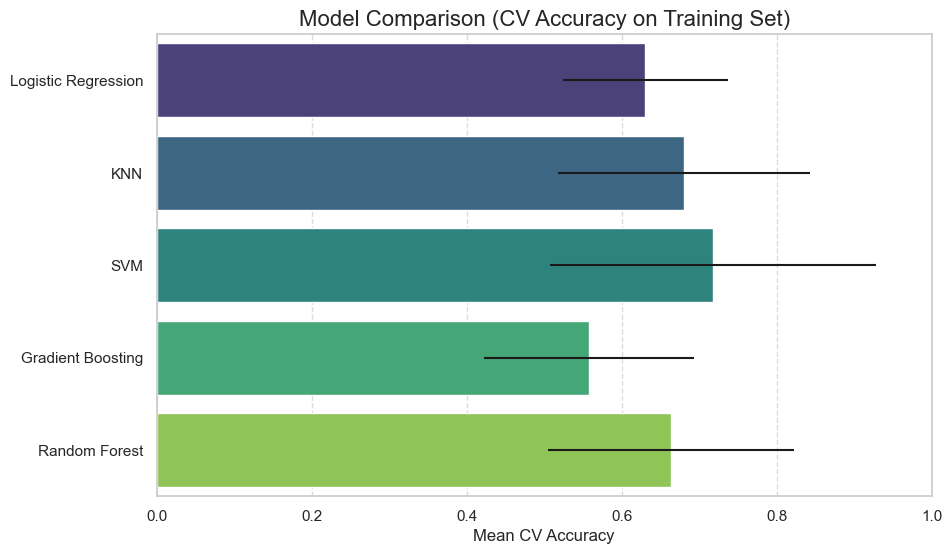

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Dizionario dei modelli da testare
models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=7, min_samples_split=5, 
                                            min_samples_leaf=2, max_features='sqrt', 
                                            random_state=42, class_weight='balanced')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Model Comparison (5-Fold Cross Validation Accuracy) ---")
results = {}
for name, model in models.items():
    # Eseguiamo la cross-validation sull'accuracy
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    results[name] = {
        'mean_acc': np.mean(cv_scores),
        'std_acc': np.std(cv_scores)
    }
    print(f"{name:<20}: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Plot dei risultati
import matplotlib.pyplot as plt
import seaborn as sns

names = list(results.keys())
means = [results[n]['mean_acc'] for n in names]
stds = [results[n]['std_acc'] for n in names]

plt.figure(figsize=(10, 6))
sns.barplot(x=means, y=names, xerr=stds, palette="viridis")
plt.title('Model Comparison (CV Accuracy on Training Set)', fontsize=16)
plt.xlabel('Mean CV Accuracy', fontsize=12)
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
